# 1.Facebook GRAPH CONSTRUCTION

POST-POST HOMOPHILY GRAPH

In [1]:
import pandas as pd
import networkx as nx
from itertools import combinations
df = pd.read_csv(
    "../../data_preprocess/processed_data/graph_data/facebook_graph.csv"
)
print("FACEBOOK GRAPH DATA")
print(df.shape)

FACEBOOK GRAPH DATA
(7527, 30)


In [2]:
import pandas as pd
import numpy as np
import time

overall_start = time.time()

# 1. GENERATE NODES
nodes_df = df.copy().rename(columns={"post_id": "Id"})
nodes_df["Label"] = nodes_df["Id"]
nodes_df.to_csv("fb_node.csv", index=False, encoding='utf-8')

# 2. GENERATE EDGES (FACEBOOK COMMUNITY HOMOPHILY)
edges_list = []

# Sorted by followers
sorted_df = df.sort_values(by=['followers'], ascending=True)

#A. Location
if 'location' in sorted_df.columns:
    print("Processing Facebook Regional Homophily (Location)...")
    for loc, group in sorted_df.groupby('location'):
        if pd.isna(loc) or loc == 'Unknown': continue
        ids = group['post_id'].values
        if len(ids) < 2: continue
        for i in range(len(ids) - 1):
            edges_list.append({
                "Source": ids[i], 
                "Target": ids[i+1],
                "Weight": 2.0,
                "Relation": "same_location"
            })

# --- B.TOPIC, LANGUAGE ---
# Based on Top Feature: Travel, Technology, Science, Entertainment
cat_features = ['topic', 'language']

for feat in cat_features:
    if feat not in sorted_df.columns: continue
    print(f"Processing Facebook Interest Homophily: {feat}...")
    
    for val, group in sorted_df.groupby(feat):
        if pd.isna(val): continue
        ids = group['post_id'].values
        if len(ids) < 2: continue
        
        for i in range(len(ids) - 1):
            # Increase weight for hot FB topics: Travel, Tech, Science
            weight = 1.5 if val in ['Travel', 'Technology', 'Science'] else 1.0
            edges_list.append({
                "Source": ids[i], 
                "Target": ids[i+1],
                "Weight": weight, 
                "Relation": feat
            })

# --- C. MEDIA TYPE (TEXT, IMAGE, VIDEO) ---
if 'media_type' in sorted_df.columns:
    print("Processing Facebook Content Type Homophily...")
    for m_type, group in sorted_df.groupby('media_type'):
        ids = group['post_id'].values
        if len(ids) < 2: continue
        for i in range(len(ids) - 1):
            edges_list.append({
                "Source": ids[i], 
                "Target": ids[i+1],
                "Weight": 1.2 if m_type == 'Text' else 0.8, 
                "Relation": "media_homophily"
            })

# --- D. TOXICITY & VERIFIED
if 'toxicity_score' in sorted_df.columns:
    print("Processing Facebook Toxicity Vibe...")
    temp_df = sorted_df.copy()
    temp_df['toxic_bins'] = temp_df['toxicity_score'].apply(lambda x: round(x/10)*10)
    
    for val, group in temp_df.groupby('toxic_bins'):
        ids = group['post_id'].values
        if len(ids) < 2: continue
        for i in range(len(ids) - 1):
            edges_list.append({
                "Source": ids[i], 
                "Target": ids[i+1],
                "Weight": 0.9, 
                "Relation": "toxicity_vibe"
            })

# --- E.USER-ID ---
print("Processing Facebook Author Clusters...")
for user_id, group in sorted_df.groupby('user_id'):
    ids = group['post_id'].values
    if len(ids) >= 2:
        for i in range(len(ids) - 1):
            edges_list.append({
                "Source": ids[i], 
                "Target": ids[i+1],
                "Weight": 2.0, 
                "Relation": "same_author"
            })
# 3. CLEAN & EXPORT
edges_df = pd.DataFrame(edges_list)
if not edges_df.empty:
    edges_df[['Source', 'Target']] = np.sort(edges_df[['Source', 'Target']], axis=1)
    edges_df = edges_df.drop_duplicates(subset=['Source', 'Target', 'Relation'])
    edges_df = edges_df[edges_df['Source'] != edges_df['Target']]

edges_df.to_csv("fb_edge.csv", index=False, encoding='utf-8')

print(f"\n--- FACEBOOK GRAPH ---")
print(f"Nodes: {len(nodes_df):,}")
print(f"Edges: {len(edges_df):,}")
print(f"Time: {round(time.time() - overall_start, 2)}s")

Processing Facebook Regional Homophily (Location)...
Processing Facebook Interest Homophily: topic...
Processing Facebook Interest Homophily: language...
Processing Facebook Content Type Homophily...
Processing Facebook Toxicity Vibe...
Processing Facebook Author Clusters...

--- FACEBOOK GRAPH ---
Nodes: 7,527
Edges: 37,416
Time: 1.25s


In [4]:
import pandas as pd
graph_df = pd.read_csv(
    "fb-result-4.csv"
)
print("GRAPH FEATURES DATA")
print(graph_df.shape)

print("\nColumns:")
print(graph_df.columns.tolist())

GRAPH FEATURES DATA
(7527, 43)

Columns:
['Id', 'platform', 'hour_of_day', 'day_of_week', 'is_weekend', 'user_id', 'followers', 'account_age_days', 'verified', 'topic', 'language', 'content_length', 'media_type', 'num_hashtags', 'sentiment_category', 'sentiment_positive', 'sentiment_negative', 'sentiment_neutral', 'toxicity_score', 'location', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'has_media', 'many_hashtags', 'long_content', 'sentiment_intensity', 'high_toxicity', 'popularity', 'modularity_class', 'stat_inf_class', 'clustering', 'triangles', 'eigencentrality', 'Eccentricity', 'closnesscentrality', 'harmonicclosnesscentrality', 'betweenesscentrality', 'Authority', 'Hub', 'pageranks', 'componentnumber']


In [5]:
# SELECT ONLY USEFUL GRAPH FEATURES
graph_features = graph_df[[
    "Id",
    "betweenesscentrality",
    "eigencentrality",
    "pageranks",
    "closnesscentrality",
    "modularity_class"
]]
graph_features = graph_features.rename(
    columns={
        "Id": "post_id"
    }
)

print("\nGraph Features Shape:")
print(graph_features.shape)



Graph Features Shape:
(7527, 6)


In [6]:
original_df = df.copy()

# REMOVE DUPLICATES
original_df = original_df.drop_duplicates(
    subset=["post_id"]
)

In [7]:
# MERGE POST_ID BACK TO TRAIN/TEST
# recreate metadata version

metadata_df = original_df.copy()

remove_cols = [
    
    "timestamp",
    "date",
    "platform",
    "likes",
    "shares",
    "comments",
    "views",
    "total_engagement",
    "engagement_rate_per_1k_followers",
    "viral_coefficient",
    "cross_platform_spread",
    "hours_since_post"
]

existing_remove_cols = [

    col for col in remove_cols
    if col in metadata_df.columns
]

metadata_df = metadata_df.drop(
    columns=existing_remove_cols
)


In [8]:
# LOAD FACEBOOK TRAIN / TEST

train_df = pd.read_csv(
    "../../data_preprocess/processed_data/ml_data/facebook_train.csv"
)

test_df = pd.read_csv(
    "../../data_preprocess/processed_data/ml_data/facebook_test.csv"
)

print("METADATA DATASETS")
print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

METADATA DATASETS
Train Shape: (6021, 56)
Test Shape : (1506, 56)


In [9]:
# MERGE TRAIN

train_hybrid = train_df.merge(
    graph_features,
    on="post_id",
    how="left"
)

# MERGE TEST
test_hybrid = test_df.merge(
    graph_features,
    on="post_id",
    how="left"
)

In [ ]:
print("\n" + "="*30)
print("TRAIN CLASS DISTRIBUTION")
print("="*30)
print(train_df["popularity"].value_counts())
print("\nProportion %:")
print(train_df["popularity"].value_counts(normalize=True) * 100)

print("\n" + "="*30)
print("TEST CLASS DISTRIBUTION")
print("="*30)
print(test_df["popularity"].value_counts())
print("\nProportion %:")
print(test_df["popularity"].value_counts(normalize=True) * 100)


TRAIN CLASS DISTRIBUTION
popularity
0    4812
1    1209
Name: count, dtype: int64

Proportion %:
popularity
0    79.920279
1    20.079721
Name: proportion, dtype: float64

TEST CLASS DISTRIBUTION
popularity
0    1204
1     302
Name: count, dtype: int64

Proportion %:
popularity
0    79.946879
1    20.053121
Name: proportion, dtype: float64


In [11]:
negative_count = train_df["popularity"].value_counts()[0]
positive_count = train_df["popularity"].value_counts()[1]

ratio = negative_count / positive_count
print(f"scale_pos_weight = {ratio:.2f}")

scale_pos_weight = 3.98


In [13]:
# FILL MISSING VALUES 
numeric_graph_cols = [
    "betweenesscentrality",
    "eigencentrality",
    "pageranks",
    "closnesscentrality",
]

existing_numeric_cols = [col for col in numeric_graph_cols if col in train_hybrid.columns]

if "modularity_class" in train_hybrid.columns:
    train_hybrid["modularity_class"] = train_hybrid["modularity_class"].fillna(-1)
    test_hybrid["modularity_class"]  = test_hybrid["modularity_class"].fillna(-1)

train_hybrid[existing_numeric_cols] = train_hybrid[existing_numeric_cols].fillna(0)
test_hybrid[existing_numeric_cols]  = test_hybrid[existing_numeric_cols].fillna(0)

X_train_cols = train_hybrid.columns
test_hybrid = test_hybrid.reindex(columns=X_train_cols, fill_value=0)

print("HYBRID DATASETS")

print(f"Train Hybrid: {train_hybrid.shape}")
print(f"Test Hybrid : {test_hybrid.shape}")

HYBRID DATASETS
Train Hybrid: (6021, 61)
Test Hybrid : (1506, 61)


In [14]:
for df_tmp in [train_hybrid, test_hybrid]:
    if "modularity_class" in df_tmp.columns:
        df_tmp["modularity_class"] = "comm_" + df_tmp["modularity_class"].astype(str)

categorical_cols = ["topic", "language", "media_type", "sentiment_category", "location", "modularity_class"]
existing_cats = [col for col in categorical_cols if col in train_hybrid.columns]

train_hybrid = pd.get_dummies(train_hybrid, columns=existing_cats, drop_first=True, dtype=int)
test_hybrid = pd.get_dummies(test_hybrid, columns=existing_cats, drop_first=True, dtype=int)

train_cols = train_hybrid.columns
test_hybrid = test_hybrid.reindex(columns=train_cols, fill_value=0)

print(f"Number of features currently: {train_hybrid.shape[1]}")

Number of features currently: 88


In [15]:
train_hybrid.to_csv(
    "facebook_hybrid_train.csv",
    index=False
)

test_hybrid.to_csv(
    "facebook_hybrid_test.csv",
    index=False
)

In [16]:
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [17]:
train_df = pd.read_csv(
    "facebook_hybrid_train.csv"
)

test_df = pd.read_csv(
    "facebook_hybrid_test.csv"
)
print("HYBRID DATASETS")
print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

HYBRID DATASETS
Train Shape: (6021, 88)
Test Shape : (1506, 88)


In [18]:
drop_cols = [

    "post_id",
    "user_id"
]

existing_drop_cols = [

    col for col in drop_cols
    if col in train_df.columns
]

train_df = train_df.drop(
    columns=existing_drop_cols
)

test_df = test_df.drop(
    columns=existing_drop_cols
)

In [19]:
# SPLIT FEATURES / TARGET
X_train = train_df.drop(
    columns=["popularity"]
)

y_train = train_df["popularity"]

X_test = test_df.drop(
    columns=["popularity"]
)

y_test = test_df["popularity"]

print("\nX_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)


X_train Shape: (6021, 85)
X_test Shape : (1506, 85)


In [20]:
from xgboost import XGBClassifier
model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=ratio,     
    n_estimators=500,           
    learning_rate=0.02,         
    max_depth=6,                
    min_child_weight=1,         
    gamma=0.1,                  
    subsample=0.8,              
    colsample_bytree=0.5,       
    random_state=42,            
    n_jobs=-1                   
)

In [21]:
print("TRAINING HYBRID MODEL...")

model.fit(
    X_train,
    y_train
)

TRAINING HYBRID MODEL...


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.5
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [22]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

In [23]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

In [24]:
print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred
    )
)

print(f"ROC-AUC  : {roc_auc:.4f}")


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.92      0.82      0.87      1204
           1       0.51      0.73      0.60       302

    accuracy                           0.81      1506
   macro avg       0.72      0.78      0.74      1506
weighted avg       0.84      0.81      0.82      1506

ROC-AUC  : 0.8613


In [26]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print("CONFUSION MATRIX")
print(cm)

CONFUSION MATRIX
[[992 212]
 [ 81 221]]


In [27]:
importance_df = pd.DataFrame({

    "feature": X_train.columns,
    "importance": model.feature_importances_

})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print("\n" + "=" * 60)
print("TOP 15 IMPORTANT FEATURES")
print("=" * 60)

print(
    importance_df.head(15)
)


TOP 15 IMPORTANT FEATURES
                     feature  importance
65  modularity_class_comm_17    0.113715
61  modularity_class_comm_13    0.061305
79   modularity_class_comm_4    0.057434
3                  followers    0.046203
78   modularity_class_comm_3    0.038565
64  modularity_class_comm_16    0.033986
58  modularity_class_comm_10    0.031582
76  modularity_class_comm_27    0.029155
74  modularity_class_comm_25    0.028081
68   modularity_class_comm_2    0.027558
73  modularity_class_comm_24    0.026572
71  modularity_class_comm_22    0.026025
67  modularity_class_comm_19    0.022553
81   modularity_class_comm_6    0.017555
80   modularity_class_comm_5    0.017347


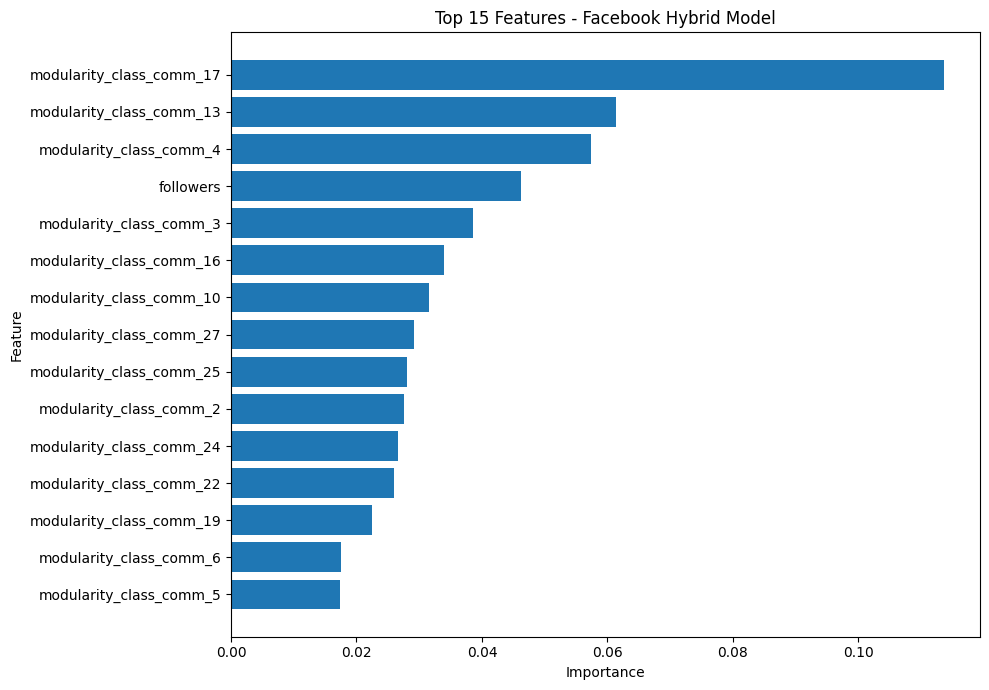

In [28]:
import matplotlib.pyplot as plt

top_n = 15

plot_df = importance_df.head(top_n)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_df["feature"][::-1],
    plot_df["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Top 15 Features - Facebook Hybrid Model"
)

plt.tight_layout()

plt.show()

# 2. FACEBOOK NODE2VEC

 GRAPH EMBEDDING

In [29]:
import pandas as pd
import os
import networkx as nx

import time

start_time = time.time()
edges_df = pd.read_csv("fb_edge.csv") 

G = nx.from_pandas_edgelist(
    edges_df, 
    source="Source", 
    target="Target", 
    create_using=nx.Graph()
)

print(f"Graph Created | Nodes: {G.number_of_nodes():,} | Edges: {G.number_of_edges():,}")

print("TRAINING NODE2VEC (MULTI-CORE)...")
Number_cpu_cores = os.cpu_count()
print(f"Number of CPU Cores: {Number_cpu_cores}")





Graph Created | Nodes: 7,527 | Edges: 31,490
TRAINING NODE2VEC (MULTI-CORE)...
Number of CPU Cores: 22


In [32]:
from node2vec import Node2Vec
import time

node2vec = Node2Vec(
    G,
    dimensions=8,        
    walk_length=10,      
    num_walks=20,        
    workers=Number_cpu_cores, 
    seed=42,
    quiet=False          
)

model = node2vec.fit(
    window=5, 
    min_count=1, 
    batch_words=4     
)

print("\nNode2Vec completed")

print(f"\nNode2Vec completed after: {round((time.time() - start_time)/60, 2)} minutes ")



Computing transition probabilities:   0%|          | 0/7527 [00:00<?, ?it/s]


Node2Vec completed

Node2Vec completed after: 12.2 minutes 


In [33]:
node_ids = list(model.wv.index_to_key)
embeddings = model.wv.vectors

emb_df = pd.DataFrame(embeddings, columns=[f"emb_{i}" for i in range(8)])
emb_df["post_id"] = node_ids 
emb_df = emb_df[emb_df['post_id'].astype(str).str.startswith('FAC')]
emb_df.to_csv("facebook_node2vec_8dims.csv", index=False)
print(f"Saved {len(emb_df)} vectors of Post articles")

Saved 7527 vectors of Post articles


In [34]:
# FACEBOOK NODE2VEC HYBRID MODEL
# METADATA + NODE2VEC EMBEDDINGS

import pandas as pd
import numpy as np

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

import matplotlib.pyplot as plt

In [35]:
train_df = pd.read_csv(
    "../../data_preprocess/processed_data/ml_data/facebook_train.csv"
)

test_df = pd.read_csv(
    "../../data_preprocess/processed_data/ml_data/facebook_test.csv"
)
print("METADATA DATA")
print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

METADATA DATA
Train Shape: (6021, 56)
Test Shape : (1506, 56)


In [36]:
embedding_df = pd.read_csv(
    "facebook_node2vec_8dims.csv"
)

print("NODE2VEC EMBEDDINGS")
print(embedding_df.shape)
print("\nEmbedding Columns:")
print(embedding_df.columns[:10])

NODE2VEC EMBEDDINGS
(7527, 9)

Embedding Columns:
Index(['emb_0', 'emb_1', 'emb_2', 'emb_3', 'emb_4', 'emb_5', 'emb_6', 'emb_7',
       'post_id'],
      dtype='str')


In [37]:
# MERGE TRAIN
train_hybrid = train_df.merge(
    embedding_df,
    on="post_id",
    how="left"
)

# MERGE TEST
test_hybrid = test_df.merge(
    embedding_df,
    on="post_id",
    how="left"
)

In [38]:
print("MISSING EMBEDDINGS CHECK")

embedding_cols = [

    col for col in embedding_df.columns
    if col.startswith("n2v_")
]

print("\nTrain Missing:")
print(
    train_hybrid[
        embedding_cols
    ].isnull().sum().sum()
)

print("\nTest Missing:")
print(
    test_hybrid[
        embedding_cols
    ].isnull().sum().sum()
)

# FILL MISSING EMBEDDINGS
train_hybrid[embedding_cols] = train_hybrid[
    embedding_cols
].fillna(0)

test_hybrid[embedding_cols] = test_hybrid[
    embedding_cols
].fillna(0)

# DROP ID COLUMNS
drop_cols = [
    "post_id",
    "user_id"
]

existing_drop_cols = [
    col for col in drop_cols
    if col in train_hybrid.columns
]

train_hybrid = train_hybrid.drop(
    columns=existing_drop_cols
)

test_hybrid = test_hybrid.drop(
    columns=existing_drop_cols
)

MISSING EMBEDDINGS CHECK

Train Missing:
0.0

Test Missing:
0.0


In [39]:
X_train = train_hybrid.drop(
    columns=["popularity"]
)
y_train = train_hybrid["popularity"]

X_test = test_hybrid.drop(
    columns=["popularity"]
)
y_test = test_hybrid["popularity"]

print("FINAL DATA")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)


FINAL DATA
X_train: (6021, 61)
X_test : (1506, 61)


In [41]:
from xgboost import XGBClassifier
model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=ratio,      
    n_estimators=500,            
    learning_rate=0.05,          
    max_depth=5,                 
    subsample=0.8,               
    colsample_bytree=0.5,        
    colsample_bylevel=0.5,
    reg_alpha=1.0,               
    reg_lambda=2.0,              
    random_state=42,
    n_jobs=-1
)

In [42]:
print("TRAINING NODE2VEC HYBRID MODEL...")
model.fit(
    X_train,
    y_train
)
print("Training completed ")

# PREDICTIONS
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

TRAINING NODE2VEC HYBRID MODEL...
Training completed 


In [43]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

In [44]:
print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred
    )
)
print(f"ROC-AUC  : {roc_auc:.4f}")


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.91      0.85      0.88      1204
           1       0.53      0.69      0.60       302

    accuracy                           0.81      1506
   macro avg       0.72      0.77      0.74      1506
weighted avg       0.84      0.81      0.82      1506

ROC-AUC  : 0.8488


In [45]:
importance_df = pd.DataFrame({

    "feature": X_train.columns,
    "importance": model.feature_importances_

})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print("\n" + "=" * 60)
print("TOP 20 IMPORTANT FEATURES")
print("=" * 60)

print(
    importance_df.head(20)
)


TOP 20 IMPORTANT FEATURES
                feature  importance
3             followers    0.143224
59                emb_6    0.031315
58                emb_5    0.025101
54                emb_1    0.024628
60                emb_7    0.023382
57                emb_4    0.021122
55                emb_2    0.020582
39    language_Japanese    0.019031
56                emb_3    0.018972
53                emb_0    0.018723
21        topic_Climate    0.016597
44      media_type_Poll    0.016049
34     language_Chinese    0.015925
5              verified    0.015727
6        content_length    0.015393
18  sentiment_intensity    0.015234
4      account_age_days    0.014813
10       toxicity_score    0.014810
9    sentiment_negative    0.014563
30        topic_Science    0.014416


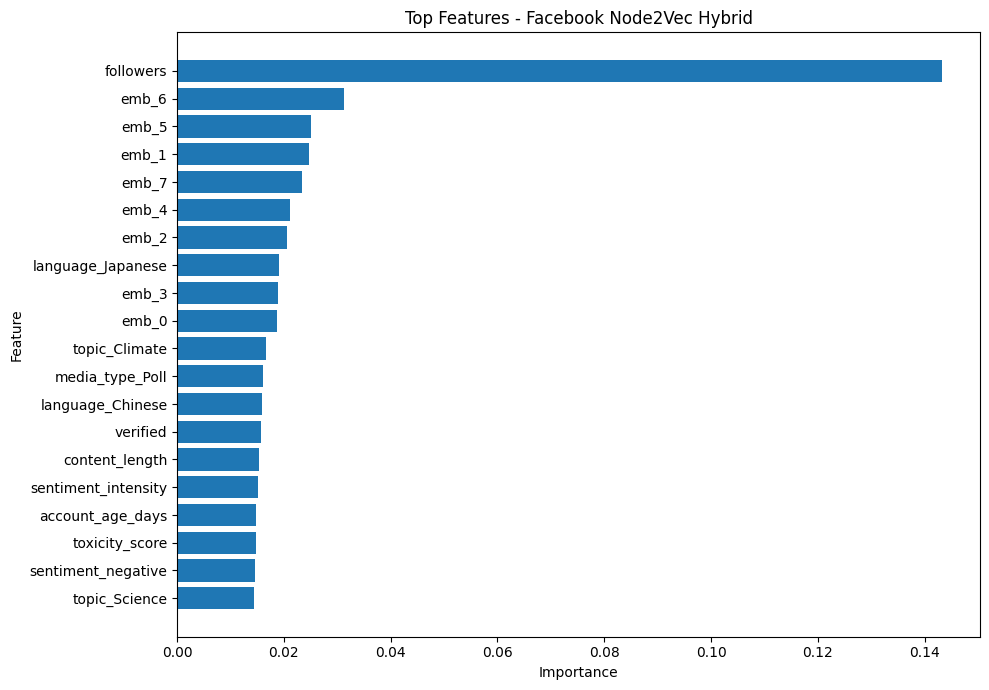

In [46]:
top_n = 20

plot_df = importance_df.head(top_n)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_df["feature"][::-1],
    plot_df["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Top Features - Facebook Node2Vec Hybrid"
)

plt.tight_layout()

plt.show()

# 3. Facebook graph + Node2vector

In [47]:
selected_n2v = ["emb_2", "emb_7", "emb_4", "emb_0", "emb_6", "emb_5", "emb_3", "emb_1"]
embedding_df_filtered = embedding_df[["post_id"] + [c for c in selected_n2v if c in embedding_df.columns]]
print(f"Selected columns: {embedding_df_filtered.columns.tolist()}")

Selected columns: ['post_id', 'emb_2', 'emb_7', 'emb_4', 'emb_0', 'emb_6', 'emb_5', 'emb_3', 'emb_1']


In [49]:
train_df = pd.read_csv(
    "facebook_hybrid_train.csv"
)

test_df = pd.read_csv(
    "facebook_hybrid_test.csv"
)

print("GRAPH HYBRID DATA")
print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

# LOAD NODE2VEC EMBEDDINGS
print("NODE2VEC EMBEDDINGS")
print(embedding_df.shape)

# CHECK EMBEDDING KEYS
print("\nEmbedding Columns:")
print(embedding_df.columns)


GRAPH HYBRID DATA
Train Shape: (6021, 88)
Test Shape : (1506, 88)
NODE2VEC EMBEDDINGS
(7527, 9)

Embedding Columns:
Index(['emb_0', 'emb_1', 'emb_2', 'emb_3', 'emb_4', 'emb_5', 'emb_6', 'emb_7',
       'post_id'],
      dtype='str')


In [50]:
train_final = train_df.merge(embedding_df_filtered, on="post_id", how="left")
test_final = test_df.merge(embedding_df_filtered, on="post_id", how="left")
print(f"Train Shape: {train_final.shape} | Test Shape: {test_final.shape}")

Train Shape: (6021, 96) | Test Shape: (1506, 96)


In [51]:
actual_emb_cols = [col for col in train_final.columns if col.startswith("emb_")]

print(f"\n🔍 Checking {len(actual_emb_cols)} embedding columns...")

train_final[actual_emb_cols] = train_final[actual_emb_cols].fillna(0)
test_final[actual_emb_cols] = test_final[actual_emb_cols].fillna(0)

print(f"Missing values after filling: {train_final[actual_emb_cols].isnull().sum().sum()}")


🔍 Checking 8 embedding columns...
Missing values after filling: 0


In [52]:
drop_cols = ["post_id", "user_id"]
existing_drop_cols = [col for col in drop_cols if col in train_final.columns]

train_final = train_final.drop(columns=existing_drop_cols)
test_final = test_final.drop(columns=existing_drop_cols)

print(f"Final dataset has {train_final.shape[1]} features.")

Final dataset has 94 features.


In [53]:
X_train = train_final.drop(
    columns=["popularity"]
)

y_train = train_final["popularity"]

X_test = test_final.drop(
    columns=["popularity"]
)

y_test = test_final["popularity"]

print("FINAL FEATURE SPACE")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

FINAL FEATURE SPACE
X_train: (6021, 93)
X_test : (1506, 93)


In [78]:
from xgboost import XGBClassifier
model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=ratio,     
    n_estimators=500,           
    learning_rate=0.02,         
    max_depth=6,                
    min_child_weight=1,         
    gamma=0.1,                 
    subsample=0.8,              
    colsample_bytree=0.5,       
    random_state=42,            
    n_jobs=-1                  
)

In [79]:
# TRAIN MODEL
print("TRAINING FINAL FACEBOOK META + GRAPH + EMBEDDING...")
model.fit(
    X_train,
    y_train
)
print("\nTraining completed ")

# PREDICTIONS
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

TRAINING FINAL FACEBOOK META + GRAPH + EMBEDDING...

Training completed 


In [80]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)


In [81]:
print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred
    )
)
print(f"ROC-AUC  : {roc_auc:.4f}")


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.92      0.83      0.87      1204
           1       0.51      0.70      0.59       302

    accuracy                           0.81      1506
   macro avg       0.71      0.76      0.73      1506
weighted avg       0.83      0.81      0.82      1506

ROC-AUC  : 0.8584


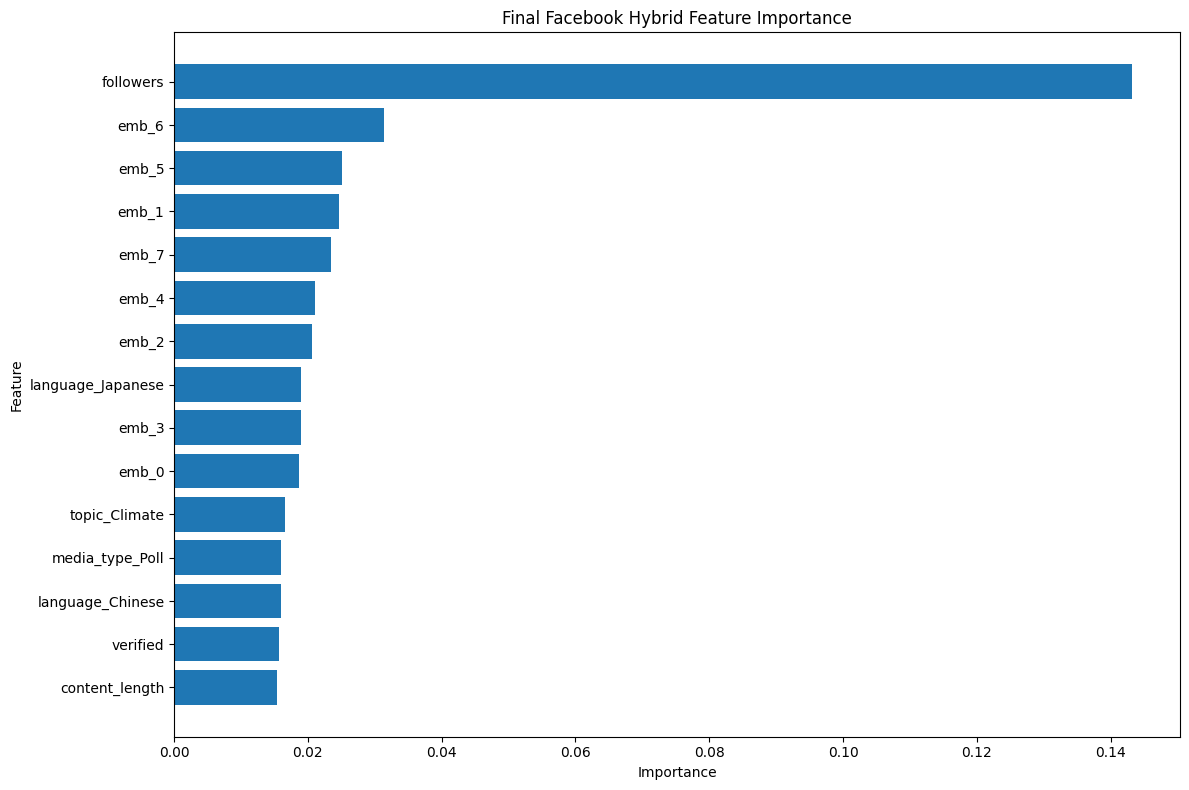

In [82]:
top_n = 15

plot_df = importance_df.head(top_n)

plt.figure(figsize=(12, 8))

plt.barh(

    plot_df["feature"][::-1],

    plot_df["importance"][::-1]
)

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.title(
    "Final Facebook Hybrid Feature Importance"
)

plt.tight_layout()

plt.show()